<a href="https://colab.research.google.com/github/deekshdechamma/DL_skill_developer/blob/main/dl2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 2: Empirical Diagnostic of Custom Weight Initializations and
Gradient Vanishing
● Objective: Solve mathematical training instability in deep networks by analyzing activation
distributions and gradient magnitudes under varying initialization distributions.
● Required Tech Stack: PyTorch (with Autograd explicitly disabled via
requires_grad=False), NumPy, Matplotlib.
● Task Description: Students will design custom Xavier (Glorot) and Kaiming (He) weight
initialization routines. They must write a tracking harness that hooks into an uninitialized
20-layer MLP to log and plot the mean and variance of intermediate activation vectors and
weight gradients across epochs, demonstrating gradient vanishing or explosion.


In [ ]:
#Step 1 Import Libraries
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Step 2 Activation Functions
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)

In [ ]:
#Step 3 Weight Initialization
import numpy as np
#Step 3 Weight Initialization
def random_init(in_dim, out_dim):
    return np.random.randn(in_dim, out_dim) * 0.01
#Xavier Initialization
def xavier_init(in_dim, out_dim):
    std = np.sqrt(2.0 / (in_dim + out_dim))
    return np.random.randn(in_dim, out_dim) * std
#Kaiming Initialization
def kaiming_init(in_dim, out_dim):
    std = np.sqrt(2.0 / in_dim)
    return np.random.randn(in_dim, out_dim) * std

In [ ]:
#Step 4 Build a 20-Layer MLP
# Step 4: Build a 20-Layer MLP

class DeepMLP:

    def __init__(self, input_dim=100,
                 hidden_dim=100,
                 output_dim=10,
                 layers=20,
                 init="xavier"):

        self.weights = []

        dims = [input_dim] + [hidden_dim] * (layers - 1) + [output_dim]

        for i in range(len(dims) - 1):

            if init == "random":
                W = random_init(dims[i], dims[i+1])

            elif init == "xavier":
                W = xavier_init(dims[i], dims[i+1])

            elif init == "kaiming":
                W = kaiming_init(dims[i], dims[i+1])

            else:
                raise ValueError("Unknown initialization method")

            self.weights.append(W)

In [ ]:
# Step 4, 5 and 6: Deep MLP + Forward + Backward

class DeepMLP:

    def __init__(self, input_dim=100,
                 hidden_dim=100,
                 output_dim=10,
                 layers=20,
                 init="xavier"):

        self.weights = []

        dims = [input_dim] + [hidden_dim] * (layers - 1) + [output_dim]

        for i in range(len(dims) - 1):

            if init == "random":
                W = random_init(dims[i], dims[i+1])

            elif init == "xavier":
                W = xavier_init(dims[i], dims[i+1])

            elif init == "kaiming":
                W = kaiming_init(dims[i], dims[i+1])

            else:
                raise ValueError("Unknown initialization method")

            self.weights.append(W)


    def forward(self, x):

        activations = [x]
        preacts = []

        for i, W in enumerate(self.weights):

            z = activations[-1] @ W
            preacts.append(z)

            if i == len(self.weights) - 1:
                a = z
            else:
                a = relu(z)

            activations.append(a)

        return activations, preacts


    def backward(self, activations, preacts, target):

        grads = []

        output = activations[-1]

        delta = output - target

        for i in reversed(range(len(self.weights))):

            grad = activations[i].T @ delta

            grads.insert(0, grad)

            if i > 0:

                delta = delta @ self.weights[i].T

                delta *= relu_derivative(preacts[i-1])

        return grads

In [ ]:
#Step 7 Dummy Dataset
np.random.seed(42)

X=np.random.randn(128,100)

Y=np.random.randn(128,10)

In [ ]:
#Step 8 Tracking Harness
def run_experiment(init):

    model=DeepMLP(init=init)

    activation_means=[]
    activation_vars=[]

    gradient_means=[]
    gradient_vars=[]

    epochs=15

    lr=0.001

    for epoch in range(epochs):

        acts,pre=model.forward(X)

        grads=model.backward(acts,pre,Y)

        for i in range(len(model.weights)):
            model.weights[i]-=lr*grads[i]

        mean_layers=[]
        var_layers=[]

        for a in acts[1:]:

            mean_layers.append(np.mean(a))
            var_layers.append(np.var(a))

        gmean=[]
        gvar=[]

        for g in grads:

            gmean.append(np.mean(np.abs(g)))
            gvar.append(np.var(g))

        activation_means.append(mean_layers)
        activation_vars.append(var_layers)

        gradient_means.append(gmean)
        gradient_vars.append(gvar)

    return (activation_means,
            activation_vars,
            gradient_means,
            gradient_vars)

In [ ]:
#Step 9 Run Experiments
random_results=run_experiment("random")

xavier_results=run_experiment("xavier")

kaiming_results=run_experiment("kaiming")

/tmp/ipykernel_1985/1250546434.py:39: RuntimeWarning: overflow encountered in matmul
  z = activations[-1] @ W
/tmp/ipykernel_1985/1250546434.py:39: RuntimeWarning: invalid value encountered in matmul
  z = activations[-1] @ W
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:188: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


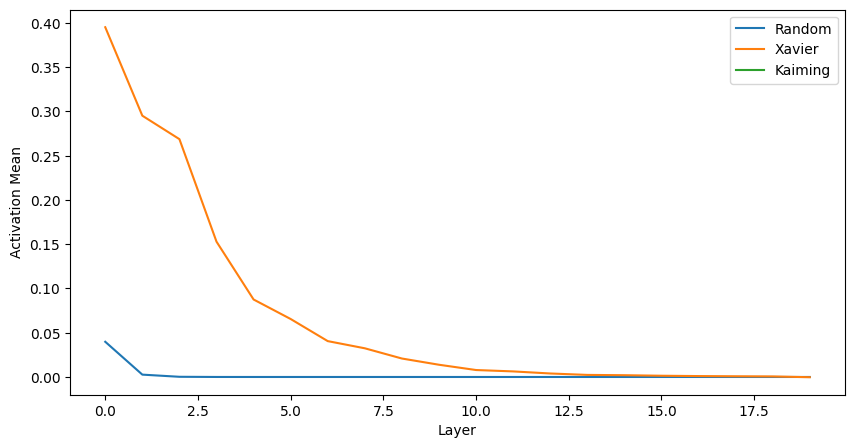

In [ ]:
#Step 10 Plot Activation Mean
plt.figure(figsize=(10,5))

plt.plot(random_results[0][-1],label="Random")

plt.plot(xavier_results[0][-1],label="Xavier")

plt.plot(kaiming_results[0][-1],label="Kaiming")

plt.xlabel("Layer")

plt.ylabel("Activation Mean")

plt.legend()

plt.show()

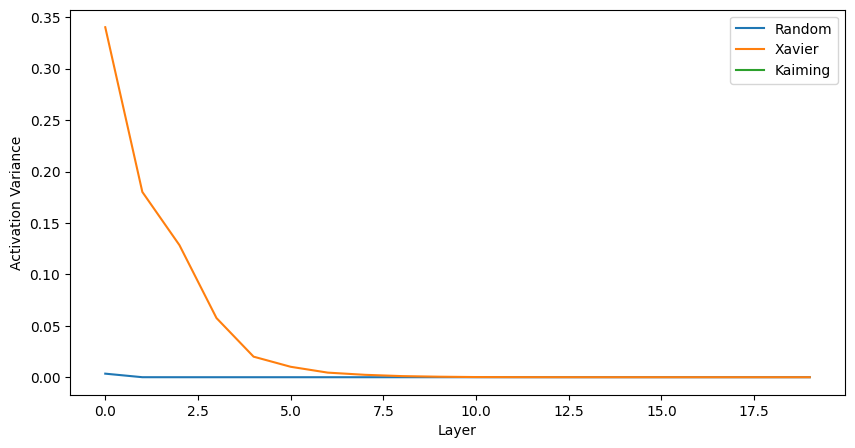

In [ ]:
#Step 11 Plot Activation Variance
plt.figure(figsize=(10,5))

plt.plot(random_results[1][-1],label="Random")

plt.plot(xavier_results[1][-1],label="Xavier")

plt.plot(kaiming_results[1][-1],label="Kaiming")

plt.xlabel("Layer")

plt.ylabel("Activation Variance")

plt.legend()

plt.show()


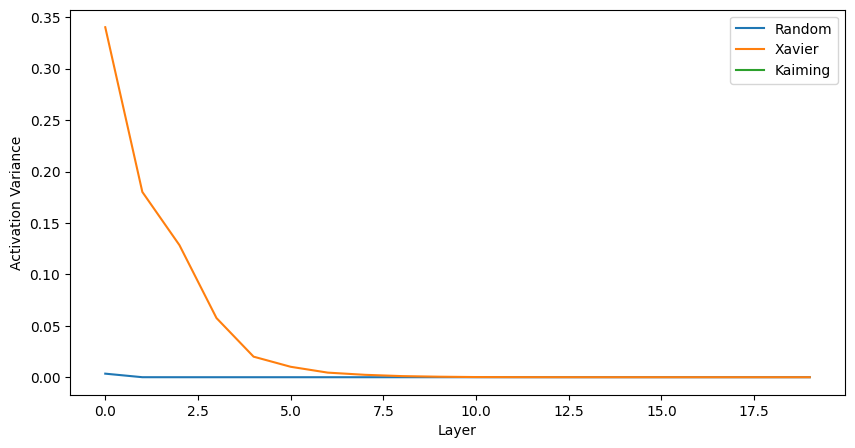

In [ ]:
#Step 11 Plot Activation Variance
plt.figure(figsize=(10,5))

plt.plot(random_results[1][-1],label="Random")

plt.plot(xavier_results[1][-1],label="Xavier")

plt.plot(kaiming_results[1][-1],label="Kaiming")

plt.xlabel("Layer")

plt.ylabel("Activation Variance")

plt.legend()

plt.show()

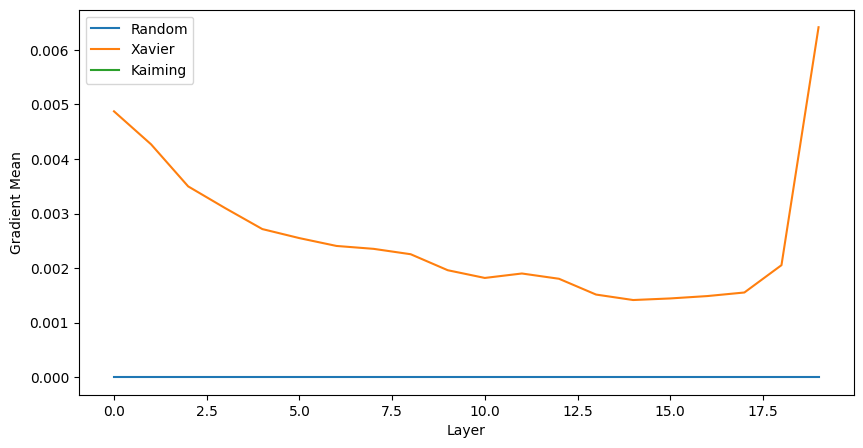

In [ ]:
#Step 12 Plot Gradient Mean
plt.figure(figsize=(10,5))

plt.plot(random_results[2][-1],label="Random")

plt.plot(xavier_results[2][-1],label="Xavier")

plt.plot(kaiming_results[2][-1],label="Kaiming")

plt.xlabel("Layer")

plt.ylabel("Gradient Mean")

plt.legend()

plt.show()

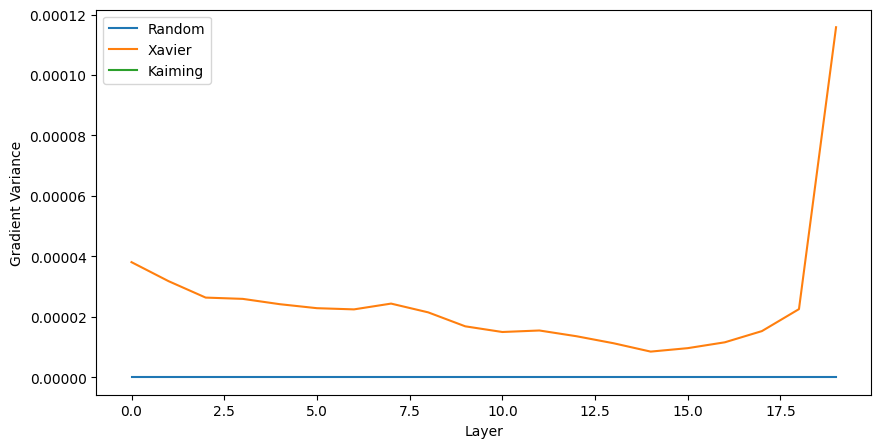

In [ ]:
#Step 13 Plot Gradient Variance
plt.figure(figsize=(10,5))

plt.plot(random_results[3][-1],label="Random")

plt.plot(xavier_results[3][-1],label="Xavier")

plt.plot(kaiming_results[3][-1],label="Kaiming")

plt.xlabel("Layer")

plt.ylabel("Gradient Variance")

plt.legend()

plt.show()